In [148]:
import os
from pathlib import Path
from shutil import copy2

In [149]:
from pathlib import Path
import os
from shutil import copy2

datasets = ["dataset1", "dataset2", "dataset3", "dataset4"]
dataset_ids = ["ds1", "ds2", "ds3", "ds4"]

merged_folder = "merged_dataset"
os.makedirs(merged_folder, exist_ok=True)

for ds_path, ds_id in zip(datasets, dataset_ids):
    ds_path = Path(ds_path)

    for class_folder in ds_path.iterdir():
        if class_folder.is_dir():   # FIXED HERE
            target_class = Path(merged_folder) / class_folder.name
            target_class.mkdir(exist_ok=True)

            for img in class_folder.iterdir():
                if img.suffix.lower() in [".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".dcm"]:
                    new_name = f"{ds_id}_{img.name}"
                    copy2(img, target_class / new_name)

print("Merge complete! All datasets are now in", merged_folder)

Merge complete! All datasets are now in merged_dataset


In [150]:
from pathlib import Path
from shutil import copy2

source_dir = Path("merged_dataset")
target_dir = Path("merged_3class")

CLASS_MAP = {
    "A": "M",
    "B": "B",
    "C": "M",
    "L": "M",
    "M": "M",
    "N": "N"
}

for cls in ["B", "M", "N"]:
    (target_dir / cls).mkdir(parents=True, exist_ok=True)

for class_folder in source_dir.iterdir():
    if not class_folder.is_dir():
        continue

    original_class = class_folder.name
    if original_class not in CLASS_MAP:
        continue

    new_class = CLASS_MAP[original_class]

    for img in class_folder.iterdir():
        if img.suffix.lower() in [
            ".png", ".jpg", ".jpeg", ".bmp",
            ".tif", ".tiff", ".dcm"
        ]:
            # unique filename
            new_name = f"{original_class}_{img.parent.name}_{img.name}"
            copy2(img, target_dir / new_class / new_name)

print("Class remapping complete without overwrites!")


Class remapping complete without overwrites!


Hashing


In [151]:
import hashlib

In [152]:
def compute_md5(file_path, block_size=65536):
    md5 = hashlib.md5()
    with open(file_path, "rb") as f:
        for chunk in iter(lambda: f.read(block_size), b""):
            md5.update(chunk)
    return md5.hexdigest()


In [153]:
DATASET_DIR = Path("merged_3class")
hash_to_file = {}      # md5 -> first seen file
duplicate_files = []  # files to be removed

valid_ext = {
    ".png", ".jpg", ".jpeg", ".bmp",
    ".tif", ".tiff", ".dcm"
}

for class_dir in DATASET_DIR.iterdir():
    if not class_dir.is_dir():
        continue

    for img_path in class_dir.iterdir():
        if img_path.suffix.lower() not in valid_ext:
            continue

        file_hash = compute_md5(img_path)

        if file_hash in hash_to_file:
            duplicate_files.append(img_path)
        else:
            hash_to_file[file_hash] = img_path


In [154]:
print(f"Total duplicate images detected: {len(duplicate_files)}")

print("\nSample duplicates:")
for dup in duplicate_files[:10]:
    print(dup)

for dup in duplicate_files:
    dup.unlink()

print("\nDuplicate images removed successfully.")


Total duplicate images detected: 2385

Sample duplicates:
merged_3class\B\B_B_ds1_100-001 (258).dcm.png
merged_3class\B\B_B_ds1_100-001 (259).dcm.png
merged_3class\B\B_B_ds1_100-001 (260).dcm.png
merged_3class\B\B_B_ds1_100-001 (261).dcm.png
merged_3class\B\B_B_ds1_100-001 (262).dcm.png
merged_3class\B\B_B_ds1_100-001 (263).dcm.png
merged_3class\B\B_B_ds1_100-001 (264).dcm.png
merged_3class\B\B_B_ds1_100-001 (265).dcm.png
merged_3class\B\B_B_ds1_100-001 (266).dcm.png
merged_3class\B\B_B_ds1_100-001 (267).dcm.png

Duplicate images removed successfully.


Stretching and Min max Normalization

In [160]:
from pathlib import Path
import cv2
import numpy as np

def enhance_contrast_extended(img, lower=-50, upper=305):
    img = img.astype(np.float32)
    orig_min = img.min()
    orig_max = img.max()
    stretched = (img - orig_min) / (orig_max - orig_min + 1e-8) * (upper - lower) + lower
    enhanced = np.clip(stretched, 0, 255)
    return enhanced.astype(np.uint8)

# Paths
dataset_dir = Path("merged_3class")          # your deduplicated dataset
enhanced_dir = Path("merged_3class_enhanced")  
enhanced_dir.mkdir(exist_ok=True)

# Process classes
for cls_folder in dataset_dir.iterdir():
    if not cls_folder.is_dir():
        continue
    target_cls_folder = enhanced_dir / cls_folder.name
    target_cls_folder.mkdir(exist_ok=True)

    for img_file in cls_folder.iterdir():
        if img_file.suffix.lower() not in [".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".dcm"]:
            continue

        img = cv2.imread(str(img_file), cv2.IMREAD_GRAYSCALE)
        enhanced_img = enhance_contrast_extended(img, lower=-50, upper=305)

        save_path = target_cls_folder / img_file.name
        cv2.imwrite(str(save_path), enhanced_img)


Hashing After Enhancement


In [161]:
from pathlib import Path
import hashlib

def compute_md5(file_path, block_size=65536):
    """
    Compute MD5 hash of a file using chunked reading
    """
    md5 = hashlib.md5()
    with open(file_path, "rb") as f:
        for block in iter(lambda: f.read(block_size), b""):
            md5.update(block)
    return md5.hexdigest()


DATASET_DIR = Path("merged_3class_enhanced")  # change if needed

hash_to_file = {}      # md5 -> first seen file
duplicate_files = []  # files to be removed

valid_ext = {
    ".png", ".jpg", ".jpeg", ".bmp",
    ".tif", ".tiff", ".dcm"
}

for class_dir in DATASET_DIR.iterdir():
    if not class_dir.is_dir():
        continue

    for img_path in class_dir.iterdir():
        if img_path.suffix.lower() not in valid_ext:
            continue

        file_hash = compute_md5(img_path)

        if file_hash in hash_to_file:
            duplicate_files.append(img_path)
        else:
            hash_to_file[file_hash] = img_path


print(f"Total duplicate images detected: {len(duplicate_files)}")

print("\nSample duplicates:")
for dup in duplicate_files[:10]:
    print(dup)

# Remove duplicates
for dup in duplicate_files:
    dup.unlink()

print("\nDuplicate images removed successfully.")


Total duplicate images detected: 2385

Sample duplicates:
merged_3class_enhanced\B\B_B_ds1_100-001 (258).dcm.png
merged_3class_enhanced\B\B_B_ds1_100-001 (259).dcm.png
merged_3class_enhanced\B\B_B_ds1_100-001 (260).dcm.png
merged_3class_enhanced\B\B_B_ds1_100-001 (261).dcm.png
merged_3class_enhanced\B\B_B_ds1_100-001 (262).dcm.png
merged_3class_enhanced\B\B_B_ds1_100-001 (263).dcm.png
merged_3class_enhanced\B\B_B_ds1_100-001 (264).dcm.png
merged_3class_enhanced\B\B_B_ds1_100-001 (265).dcm.png
merged_3class_enhanced\B\B_B_ds1_100-001 (266).dcm.png
merged_3class_enhanced\B\B_B_ds1_100-001 (267).dcm.png

Duplicate images removed successfully.


Enhancement Result

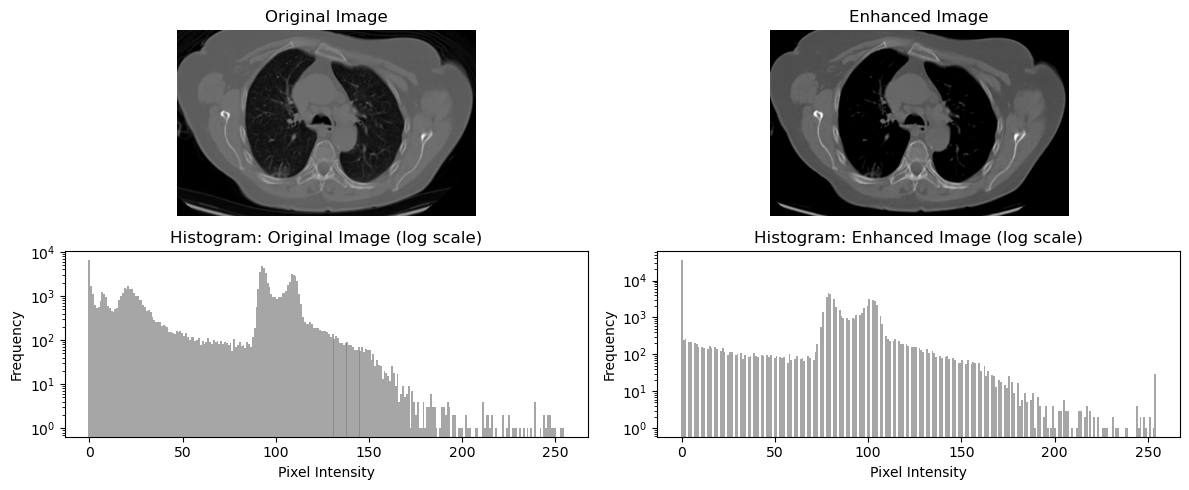

In [162]:
import matplotlib.pyplot as plt
img_path = "merged_3class/M/A_A_ds2_000005 (9).png"  # change this to your path
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# Enhance
enhanced_img = enhance_contrast_extended(img, lower=-50, upper=305)



# Original Image
plt.figure(figsize=(12,5))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(enhanced_img, cmap='gray')
plt.title("Enhanced Image")
plt.axis('off')

# Plot histograms
plt.subplot(2,2,3)
hist_orig, bins_orig = np.histogram(img.ravel(), bins=256, range=(0,255))
plt.bar(bins_orig[:-1], hist_orig, width=1, color='gray', alpha=0.7)
plt.yscale('log')  # Log frequency
plt.title("Histogram: Original Image (log scale)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.subplot(2,2,4)
hist_enh, bins_enh = np.histogram(enhanced_img.ravel(), bins=256, range=(0,255))
plt.bar(bins_enh[:-1], hist_enh, width=1, color='gray', alpha=0.7)
plt.yscale('log')  # Log frequency
plt.title("Histogram: Enhanced Image (log scale)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


In [157]:
#import sys
#print(sys.executable)


In [158]:
'''
from pathlib import Path
import cv2
import numpy as np

def stretch_and_threshold(img, lower_stretch=-64, upper_stretch=350, low_thresh=0, high_thresh=255):
    """
    Performs two-step enhancement:
    1. Linear stretch of intensity to extended range (lower_stretch → upper_stretch)
    2. Thresholding: pixels below low_thresh → 0, above high_thresh → 255,
       mid-range pixels scaled linearly to 0–255
    """
    img = img.astype(np.float32)

    # Step 1: Stretch intensities
    orig_min = img.min()
    orig_max = img.max()
    stretched = (img - orig_min) / (orig_max - orig_min + 1e-8) * (upper_stretch - lower_stretch) + lower_stretch

    # Step 2: Apply thresholds
    enhanced = np.zeros_like(stretched)
    enhanced[stretched <= low_thresh] = 0
    enhanced[stretched >= high_thresh] = 255
    mask = (stretched > low_thresh) & (stretched < high_thresh)
    enhanced[mask] = ((stretched[mask] - low_thresh) / (high_thresh - low_thresh)) * 255

    return enhanced.astype(np.uint8)


# Paths
dataset_dir = Path("merged_3class")          # Your deduplicated dataset
enhanced_dir = Path("merged_3class_enhanced")  
enhanced_dir.mkdir(exist_ok=True)

# Process classes
for cls_folder in dataset_dir.iterdir():
    if not cls_folder.is_dir():
        continue
    target_cls_folder = enhanced_dir / cls_folder.name
    target_cls_folder.mkdir(exist_ok=True)

    for img_file in cls_folder.iterdir():
        if img_file.suffix.lower() not in [".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".dcm"]:
            continue

        # Load image in grayscale
        img = cv2.imread(str(img_file), cv2.IMREAD_GRAYSCALE)

        # Apply enhancement (stretch + threshold)
        enhanced_img = stretch_and_threshold(img, lower_stretch=-50, upper_stretch=305, low_thresh=-15, high_thresh=80)

        # Save enhanced image
        save_path = target_cls_folder / img_file.name
        cv2.imwrite(str(save_path), enhanced_img)
        '''


'\nfrom pathlib import Path\nimport cv2\nimport numpy as np\n\ndef stretch_and_threshold(img, lower_stretch=-64, upper_stretch=350, low_thresh=0, high_thresh=255):\n    """\n    Performs two-step enhancement:\n    1. Linear stretch of intensity to extended range (lower_stretch → upper_stretch)\n    2. Thresholding: pixels below low_thresh → 0, above high_thresh → 255,\n       mid-range pixels scaled linearly to 0–255\n    """\n    img = img.astype(np.float32)\n\n    # Step 1: Stretch intensities\n    orig_min = img.min()\n    orig_max = img.max()\n    stretched = (img - orig_min) / (orig_max - orig_min + 1e-8) * (upper_stretch - lower_stretch) + lower_stretch\n\n    # Step 2: Apply thresholds\n    enhanced = np.zeros_like(stretched)\n    enhanced[stretched <= low_thresh] = 0\n    enhanced[stretched >= high_thresh] = 255\n    mask = (stretched > low_thresh) & (stretched < high_thresh)\n    enhanced[mask] = ((stretched[mask] - low_thresh) / (high_thresh - low_thresh)) * 255\n\n    return

In [159]:
'''

# Load an image
img_path = "merged_3class\M\A_A_ds2_000005 (3).png"  # replace with your image path
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# Apply enhancement
enhanced_img = stretch_and_threshold(img)

# Plot original vs enhanced
plt.figure(figsize=(12,5))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(enhanced_img, cmap='gray')
plt.title("Enhanced Image")
plt.axis('off')

# Plot histograms
plt.subplot(2,2,3)
hist_orig, bins_orig = np.histogram(img.ravel(), bins=256, range=(0,255))
plt.bar(bins_orig[:-1], hist_orig, width=1, color='gray', alpha=0.7)
plt.yscale('log')  # Log frequency
plt.title("Histogram: Original Image (log scale)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.subplot(2,2,4)
hist_enh, bins_enh = np.histogram(enhanced_img.ravel(), bins=256, range=(0,255))
plt.bar(bins_enh[:-1], hist_enh, width=1, color='gray', alpha=0.7)
plt.yscale('log')  # Log frequency
plt.title("Histogram: Enhanced Image (log scale)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()
'''

'\n\n# Load an image\nimg_path = "merged_3class\\M\\A_A_ds2_000005 (3).png"  # replace with your image path\nimg = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)\n\n# Apply enhancement\nenhanced_img = stretch_and_threshold(img)\n\n# Plot original vs enhanced\nplt.figure(figsize=(12,5))\n\nplt.subplot(2,2,1)\nplt.imshow(img, cmap=\'gray\')\nplt.title("Original Image")\nplt.axis(\'off\')\n\nplt.subplot(2,2,2)\nplt.imshow(enhanced_img, cmap=\'gray\')\nplt.title("Enhanced Image")\nplt.axis(\'off\')\n\n# Plot histograms\nplt.subplot(2,2,3)\nhist_orig, bins_orig = np.histogram(img.ravel(), bins=256, range=(0,255))\nplt.bar(bins_orig[:-1], hist_orig, width=1, color=\'gray\', alpha=0.7)\nplt.yscale(\'log\')  # Log frequency\nplt.title("Histogram: Original Image (log scale)")\nplt.xlabel("Pixel Intensity")\nplt.ylabel("Frequency")\n\nplt.subplot(2,2,4)\nhist_enh, bins_enh = np.histogram(enhanced_img.ravel(), bins=256, range=(0,255))\nplt.bar(bins_enh[:-1], hist_enh, width=1, color=\'gray\', alpha=0